<a href="https://colab.research.google.com/github/devpatel0005/Stock-Sentiment-Analysis-based-on-News/blob/main/Stock_Sentiment_Analysis_Using_LSTM_based_on_News.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The RandomForest Implementation

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Function to preprocess headlines
def preprocess_headlines(df_subset):
    headlines = [' '.join(str(x) for x in row if str(x) != 'nan') for row in df_subset.iloc[:,2:27].values]
    stem_headlines_subset = []
    for paragraph in headlines:
        review = []
        for word in paragraph.split():
            if word not in stop_words:
                review.append(ps.lemmatize(word))
        stem_headlines_subset.append(' '.join(review))
    return stem_headlines_subset

# Preprocess train and test headlines
stem_headlines_train = preprocess_headlines(train)
stem_headlines_test = preprocess_headlines(test)

y_train = train['Label'].values
y_test = test['Label'].values

# Vectorize the text using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = vectorizer.fit_transform(stem_headlines_train)
X_test = vectorizer.transform(stem_headlines_test)

# Train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict and evaluate
y_pred_test = rf.predict(X_test)
print("Random Forest Test Accuracy:", accuracy_score(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

# Check training accuracy
y_pred_train = rf.predict(X_train)
print("Random Forest Training Accuracy:", accuracy_score(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

Random Forest Test Accuracy: 0.8359788359788359
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       186
           1       0.82      0.86      0.84       192

    accuracy                           0.84       378
   macro avg       0.84      0.84      0.84       378
weighted avg       0.84      0.84      0.84       378

Random Forest Training Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1879
           1       1.00      1.00      1.00      2096

    accuracy                           1.00      3975
   macro avg       1.00      1.00      1.00      3975
weighted avg       1.00      1.00      1.00      3975



In [30]:
# Perform Grid Search CV to tune hyperparameters and prevent overfitting
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

best_rf = grid_search.best_estimator_

# Evaluate the best model
y_pred_test = best_rf.predict(X_test)
print("Tuned RF Test Accuracy:", accuracy_score(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

y_pred_train = best_rf.predict(X_train)
print("Tuned RF Training Accuracy:", accuracy_score(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Tuned RF Test Accuracy: 0.6084656084656085
              precision    recall  f1-score   support

           0       0.97      0.21      0.35       186
           1       0.57      0.99      0.72       192

    accuracy                           0.61       378
   macro avg       0.77      0.60      0.53       378
weighted avg       0.77      0.61      0.54       378

Tuned RF Training Accuracy: 0.6628930817610063
              precision    recall  f1-score   support

           0       0.98      0.29      0.45      1879
           1       0.61      1.00      0.76      2096

    accuracy                           0.66      3975
   macro avg       0.80      0.64      0.60      3975
weighted avg       0.79      0.66      0.61      3975



# The Transformer Implementation

ProsusAI/finbert is currently the best-performing transformer model for financial news sentiment analysis, achieving an accuracy of 88.92% in comparative studies when fine-tuned on financial data.  It is a specialized version of BERT, specifically trained on 10,000 manually annotated financial sentences from analyst reports, giving it superior context understanding for financial terminology and sentiment nuances. 

In [26]:
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer,AutoModelForSequenceClassification,Trainer,TrainingArguments
# AutoTokenizer Converts raw text into numbers (input IDs) and tensors that the model can actually "read."
# AutoModelForSequenceClassification	The Brain	Loads the pre-trained model architecture with a "classification head" on top (to output labels like Positive/Negative).     
# TrainingArguments	The Strategy	A configuration object where you define the hyperparameters (learning rate, batch size, number of epochs).
# Trainer	The Engine	The high-level API that handles the heavy lifting of the training loop, evaluation, and saving the model.
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

### Loading the Dataset

In [31]:
df = pd.read_csv("Data.csv", encoding='ISO-8859-1')

In [32]:
df.sample(5)

,Date,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top16,Top17,Top18,Top19,Top20,Top21,Top22,Top23,Top24,Top25
2251,2009-02-27,0,b'The United States has decided to boycott an ...,"b""Bullied teen gives up waiting for the school...",b'American Jewish Leaders blast Hillary Clinto...,b'Wikileaks has cracked the encryption to a ke...,"b"" As President Obama was visiting Canada last...",b'TMZ Story Forces Bank to Return $1.6 Billion...,"b'Mugabe wants Zimbabwe\'s white farmers out, ...","b""British Government 'using fear as a weapon t...",...,"b""A former Nun's memoirs rock India's Catholic...",b'100 Churches In Burma Ordered To Close',"b""Harper: 'We will defend our airspace' - Cana...",b'Canada has become the No. 1 source of ecstas...,b'Inside the world of trafficked indentured se...,b'Why did the Washington Post censor todays Do...,b'Pic of Romanian plane just as it makes crash...,"b""Mugabe says he'll seize more white farms""","b""90 year old guy takes drive of death on mobi...","b""'Old-fashioned' Scottish bank shrugs off eco..."
3839,2015-06-19,0,Germany agreed Thursday to turn more than 60 f...,Man falls to his death in London after clingin...,"Mexico to Donald Trump: You are one ignorant,'...",A Gold Coast police officer who leaked video f...,"North Korea Claims It Has Cure for MERS, Ebola...",China is utterly and totally dominating solar ...,"Trans-Pacific Partnership? Never heard of it, ...","Canada: controversial anti-terrorism bill, C-5...",...,China stocks plunge as bubble fears grow,Jobless Afghan fighters say they were paid by ...,Spain turns its back on the sun. Proposed legi...,300 arrested in global wildlife raids - Seizur...,"Armed Groups Reportedly Raped, Castrated, and ...","UK Muslims helping jihadis, says Cameron: Comm...",New DNA Results Show Kennewick Man Was Native ...,Euro zone announces emergency summit on Greece...,Pakistan suspends death penalty during Ramadan...,Exclusive - Deposit withdrawals surge at Greek...
2456,2009-12-18,1,"b""Prague TV Tower - World's Largest Spherical ...","b'""Identifying Israel as a racist, warmongerin...",b'Portugal has drawn up a proposal to allow ga...,b'Copenhagen fails! No binding agreement. No E...,b'Vancouver goes Draconian over Olympics',"b'Thieves steal Auschwitz\'s ""Work Sets You Fr...","b'Israel gets billions in aid, again. How abou...",b'Bones of Medieval women found in a village a...,...,b'Iran acknowledges prisoners were beaten to d...,b'Israelis move to seize a beautiful building ...,b'Trains stuck in Channel: Four trains have b...,b'Smugglers along the border of Egypt and the ...,b'Bolivia seizes land from owner of opposition...,"b'Nigeria rebels attack oil pipeline, putting ...","b'Beate Arnestad, director of the documentary ...","b""London 'damaged' by bonus tax, Barclays chie...",b'Rwanda - Population Growth Raises Concerns',b'The Ugly Canadian\n\nThe deep well of affect...
1047,2004-05-04,1,Deportivo La Coruña 0 - 1 Porto,Sony announces music download service,BBC takes first steps towards TV on the intern...,Deportivo La Coruna 0 - 1 Porto (Agg score: 0-1),Back to the future,"Julie Ward unlawfully killed, says coroner",ID card pilot hit by technical glitches,Grantham's 'regret' over revelations,...,Chelsea tempt Greenberg from Standard,UK 'slips down e-government table',David Aaronovitch: Whatever happened to the de...,Nick Denton's latest venture,Royal Mail factfile,Timeline: Julie Ward,"Alan Brazil, and A Very Naughty Boy",Letters: Molvanian menace,Scots top global asthma table,'No stone unturned' in Iraq torture inquiry
1178,2004-11-09,1,"'We are not here to liberate Iraq, we're here ...",Leader: Fearful in Falluja,Eurostar celebrates its 10th anniversary with ...,"Go kick some butt and make history, Vietnam-st...",US gamble on election success,Shanghaicuts,Pair jailed for spying for Britain,Home alone,...,French troops confront Ivorians,"Simon Tisdall: Stuck in France's orbit, a depr...",Unreasonable force?,Press review: Falluja,Leader: Browser 

#### Makiing the Training and testing data out of the given data

In [33]:
train = df[df['Date'] < '20150101']
test = df[df['Date'] > '20141231']

### Text preprocessing

In [34]:
def prepare_text(data):
    headlines=[]
    for row in range(0,len(data.index)):
        combined=' '.join(str(x) for x in data.iloc[row,2:27])
        clean=combined.replace("[^a-zA-Z]"," ")
        headlines.append(clean)
    return headlines

x_train,y_train=prepare_text(train),train['Label'].values
x_test,y_test=prepare_text(test),test['Label'].values

In [35]:
x_train[0],y_train[0]

("A 'hindrance to operations': extracts from the leaked reports Scorecard Hughes' instant hit buoys Blues Jack gets his skates on at ice-cold Alex Chaos as Maracana builds up for United Depleted Leicester prevail as Elliott spoils Everton's party Hungry Spurs sense rich pickings Gunners so wide of an easy target Derby raise a glass to Strupar's debut double Southgate strikes, Leeds pay the penalty Hammers hand Robson a youthful lesson Saints party like it's 1999 Wear wolves have turned into lambs Stump mike catches testy Gough's taunt Langer escapes to hit 167 Flintoff injury piles on woe for England Hunters threaten Jospin with new battle of the Somme Kohl's successor drawn into scandal The difference between men and women Sara Denver, nurse turned solicitor Diana's landmine crusade put Tories in a panic Yeltsin's resignation caught opposition flat-footed Russian roulette Sold out Recovering a title",
 0)

In [36]:
from transformers import AutoTokenizer,AutoModelForSequenceClassification,Trainer,TrainingArguments
import torch

- AutoTokenizer

Converts raw text into numbers (tokens) that a model can understand.
Handles tasks like splitting text, mapping words to IDs, padding, and truncation.
“Auto” means it automatically selects the correct tokenizer for your chosen mode

- AutoModelForSequenceClassification

Loads a pretrained model designed for classification tasks (like sentiment analysis, spam detection, etc.).
Adds a classification head (a neural network layer) on top of a base model (like BERT).
“Auto” selects the correct architecture based on the model name.

- Trainer

A high-level API that handles the training loop for you.
Manages:
Forward pass
Loss calculation
Backpropagation
Evaluation
Saves you from writing complex training code manually.

- TrainingArguments

A configuration class used by Trainer.
Defines how training should run.


### Loading the Model

In [47]:
tokenizer=AutoTokenizer.from_pretrained('ProsusAI/finbert')
# from_pretrained is used for loading a pre-trained model and its associated tokenizer from the Hugging Face model hub.
model=AutoModelForSequenceClassification.from_pretrained('ProsusAI/finbert',num_labels=2,ignore_mismatched_sizes=True)
#num_labels=2 is the number of labels for binary classification. since we have labels 0 and 1 in the Dataset

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ProsusAI/finbert and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Tokenization Function

In [49]:
#Tokenizes text, adjusts labels, and serves data in the exact format required for training a PyTorch model.
class StockSentimentDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128): # in the finbert model, the maximum sequence length is 512 tokens. If your input text exceeds this length, it will be truncated to fit within the model's limits.
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_len) #Converts all texts → numbers (input_ids, attention_mask  Ensures: Same length (padding)  No overflow (truncation)
        # Mapping: Dataset 0 -> FinBERT 1 (Neg), Dataset 1 -> FinBERT 0 (Pos)
        self.labels = [1 if l == 0 else 0 for l in labels]

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()} #Takes tokenized data at index idx Converts it to PyTorch tensors
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42
)

train_dataset = StockSentimentDataset(x_train_final, y_train_final, tokenizer, max_len=128)
val_dataset = StockSentimentDataset(x_val, y_val, tokenizer, max_len=128)

### Training Arguments

In [50]:
traning_args=TrainingArguments(
    output_dir='./results',
    num_train_epochs=4, #The model will see the entire dataset 4 times
    per_device_train_batch_size=16, #Number of samples processed at once during training
    per_device_eval_batch_size=32,
    warmup_steps=100, # Number of steps for the learning rate to increase (warmup) before it starts to decrease.
    weight_decay=0.01, # Regularization technique to prevent overfitting by adding a penalty to the loss function based on the magnitude of the model's weights.
    logging_dir='./logs',
    eval_strategy="epoch", # Evaluate the model at the end of each epoch.
    save_strategy="epoch", # Save the model at the end of each epoch.
    learning_rate=2e-5,
    fp16=True,                            # use mixed precision
    load_best_model_at_end=True, # After training, load the model that performed best on the evaluation set.

)

In [51]:
def compute_metrics(eval_pred):
    logits,labels=eval_pred # eval_pred is a tuple containing the model's raw output (logits) and the true labels for the evaluation dataset.
    predictions=np.argmax(logits,axis=-1) # Here it takes the raw output (logits) from the model and converts it into predicted class labels by selecting the index of the highest logit value for each sample.
    return {'accuracy': accuracy_score(labels,predictions)}

In [52]:
trainer= Trainer(
    model=model,
    args=traning_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)
# The Trainer class is a high-level API provided by Hugging Face's Transformers library that simplifies the training and evaluation process of transformer models. It handles the training loop, evaluation, and saving of the model based on the provided arguments and datasets.

In [53]:
trainer.train()

c:\Users\tvard\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.692557,0.522613
2,No log,0.698402,0.522613
3,0.696100,0.724252,0.489950
4,0.696100,0.771354,0.525126


c:\Users\tvard\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\tvard\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\tvard\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


TrainOutput(global_step=896, training_loss=0.6624972479684013, metrics={'train_runtime': 111.1007, 'train_samples_per_second': 128.784, 'train_steps_per_second': 8.065, 'total_flos': 941148245022720.0, 'train_loss': 0.6624972479684013, 'epoch': 4.0})

### Model Evaluation

In [54]:
results = trainer.predict(val_dataset)
y_pred = np.argmax(results.predictions, axis=-1)
y_true = results.label_ids
print("Test Accuracy:", accuracy_score(y_true, y_pred))
print("Generating predictions for Train and Test sets...")
# Predict on Test
test_results = trainer.predict(val_dataset)
y_test_pred = np.argmax(test_results.predictions, axis=-1)
y_test_true = test_results.label_ids

# Predict on Train (to check for overfitting)
train_results = trainer.predict(train_dataset)
y_train_pred = np.argmax(train_results.predictions, axis=-1)
y_train_true = train_results.label_ids
print(classification_report(y_true, y_pred))

c:\Users\tvard\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Test Accuracy: 0.5226130653266332
Generating predictions for Train and Test sets...


c:\Users\tvard\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


c:\Users\tvard\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


              precision    recall  f1-score   support

           0       0.52      1.00      0.69       208
           1       0.00      0.00      0.00       190

    accuracy                           0.52       398
   macro avg       0.26      0.50      0.34       398
weighted avg       0.27      0.52      0.36       398



c:\Users\tvard\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\tvard\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\tvard\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Confusion Matrix

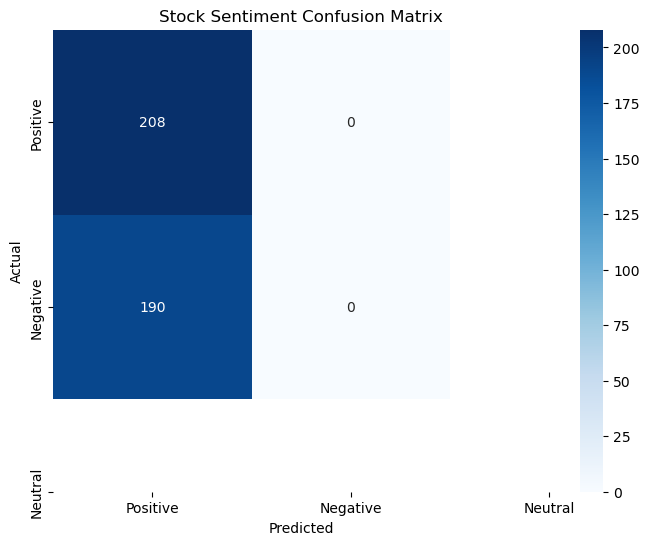

In [55]:
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Positive', 'Negative', 'Neutral'], 
            yticklabels=['Positive', 'Negative', 'Neutral'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Stock Sentiment Confusion Matrix')
plt.savefig('confusion_matrix.png')

### TEST CUSTOM NEWS (INFERENCE)

In [56]:

def quick_predict(text):
    model.eval()
    # Tokenize
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    # Move to same device as model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Get probabilities
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    prob_val, pred_idx = torch.max(probs, dim=-1)
    
    mapping = {0: "UP (Positive)", 1: "DOWN (Negative)", 2: "NEUTRAL"}
    return mapping[pred_idx.item()], prob_val.item()

# Example Usage
my_news = "Federal Reserve keeps interest rates steady; markets react with optimism."
sentiment, confidence = quick_predict(my_news)
print(f"\nCustom Test News: {my_news}")
print(f"Result: {sentiment} | Confidence: {confidence:.2%}")


Custom Test News: Federal Reserve keeps interest rates steady; markets react with optimism.
Result: UP (Positive) | Confidence: 54.75%


c:\Users\tvard\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


## Save the Model

In [ ]:
# Save the model and tokenizer to a folder
model.save_pretrained("./final_stock_model")
tokenizer.save_pretrained("./final_stock_model")
print("Model saved successfully!")